### Student Performance Indicator 

#### LifeCycle of Machine Learning Project
- Understanding the problem statement
- Data Collection
- Data Checks to Perform
- EDA
- Data Pre-Processing
- Model Training 
- Choosing the Best Model


### Problem statement

This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.

### Data Collection
Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977

The data consists of 8 column and 1000 rows.

In [ ]:
## import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
## import data for EDA
df = pd.read_csv('./data/students.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [5]:
## check if there any nulls in the dataset or not 
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
## check if there any duplicates in the dataset or not 
df.duplicated().sum()

np.int64(0)

In [8]:
## segregate categorical features
categotical_features = [feature for feature in df.columns if df[feature].dtype == 'str']
print(categotical_features)

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [12]:
for feat in categotical_features:
    print(f'Unique values for {feat} are \n {df[feat].unique().tolist()}')
    print('------------------------------------------------------')

Unique values for gender are 
 ['female', 'male']
------------------------------------------------------
Unique values for race_ethnicity are 
 ['group B', 'group C', 'group A', 'group D', 'group E']
------------------------------------------------------
Unique values for parental_level_of_education are 
 ["bachelor's degree", 'some college', "master's degree", "associate's degree", 'high school', 'some high school']
------------------------------------------------------
Unique values for lunch are 
 ['standard', 'free/reduced']
------------------------------------------------------
Unique values for test_preparation_course are 
 ['none', 'completed']
------------------------------------------------------


In [13]:
## check value counts for each category for imbalanced dataset
for feat in categotical_features:
    print(f'---------------------------------{feat}--------------------------------')
    print(df[feat].value_counts().to_dict())

---------------------------------gender--------------------------------
{'female': 518, 'male': 482}
---------------------------------race_ethnicity--------------------------------
{'group C': 319, 'group D': 262, 'group B': 190, 'group E': 140, 'group A': 89}
---------------------------------parental_level_of_education--------------------------------
{'some college': 226, "associate's degree": 222, 'high school': 196, 'some high school': 179, "bachelor's degree": 118, "master's degree": 59}
---------------------------------lunch--------------------------------
{'standard': 645, 'free/reduced': 355}
---------------------------------test_preparation_course--------------------------------
{'none': 642, 'completed': 358}


In [16]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str']
print(numerical_features)

['math_score', 'reading_score', 'writing_score']


In [18]:
df[numerical_features].corr()

,math_score,reading_score,writing_score
math_score,1.000000,0.817580,0.802642
reading_score,0.817580,1.000000,0.954598
writing_score,0.802642,0.954598,1.000000


In [19]:
df[numerical_features].describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight

- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

In [20]:
## Creating some additional column Total Score and Avg
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score'] / 3

In [21]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [23]:
## full marks in maths
print("Count of people having full marks in maths ",df[df['math_score']==100]['average'].count())
## full marks in reading
print("Count of people having full marks in reading ",df[df['reading_score']==100]['average'].count())
## full marks in writing
print("Count of people having full marks in writing ",df[df['writing_score']==100]['average'].count())

Count of people having full marks in maths  7
Count of people having full marks in reading  17
Count of people having full marks in writing  14


In [24]:
## less than 20 marks in maths
print("Count of people having less than 20 marks in maths ",df[df['math_score']<20]['average'].count())
## less than 20  marks in reading
print("Count of people having less than 20 marks in reading ",df[df['reading_score']<20]['average'].count())
## less than 20  marks in writing
print("Count of people having less than 20 marks in writing ",df[df['writing_score']<20]['average'].count())

Count of people having less than 20 marks in maths  4
Count of people having less than 20 marks in reading  1
Count of people having less than 20 marks in writing  3


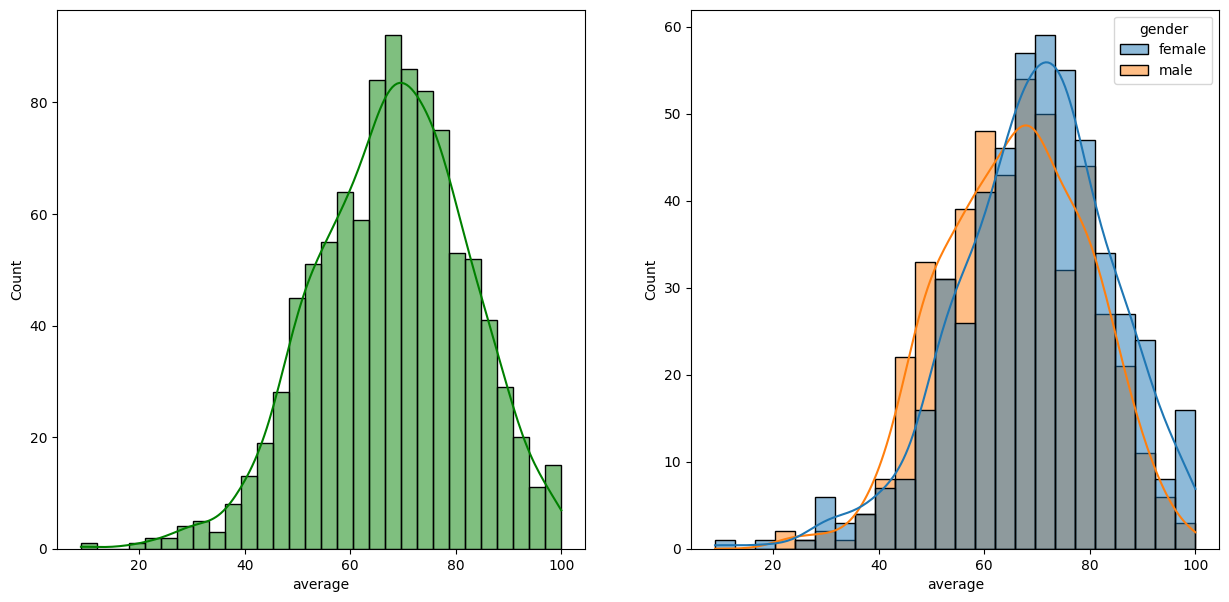

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

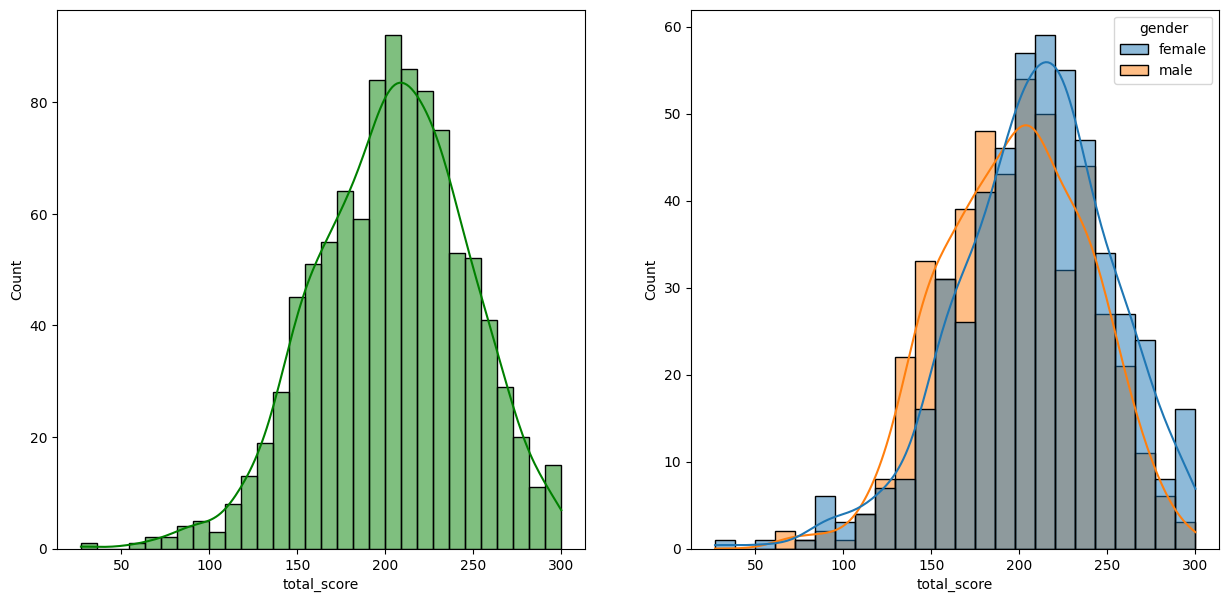

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.show()

#### Female students tends to perform well than male students

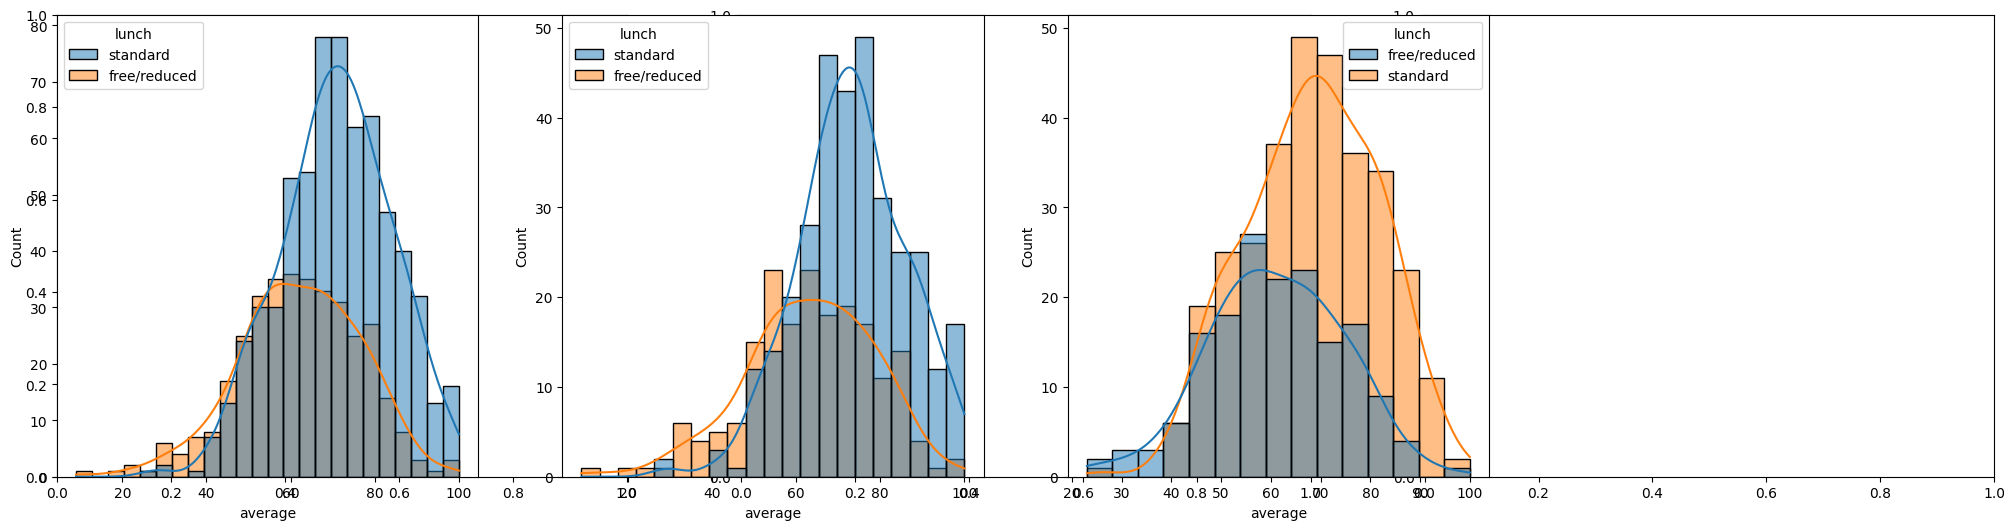

In [28]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='average',kde=True,hue='lunch') 
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='lunch')
plt.show()

- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

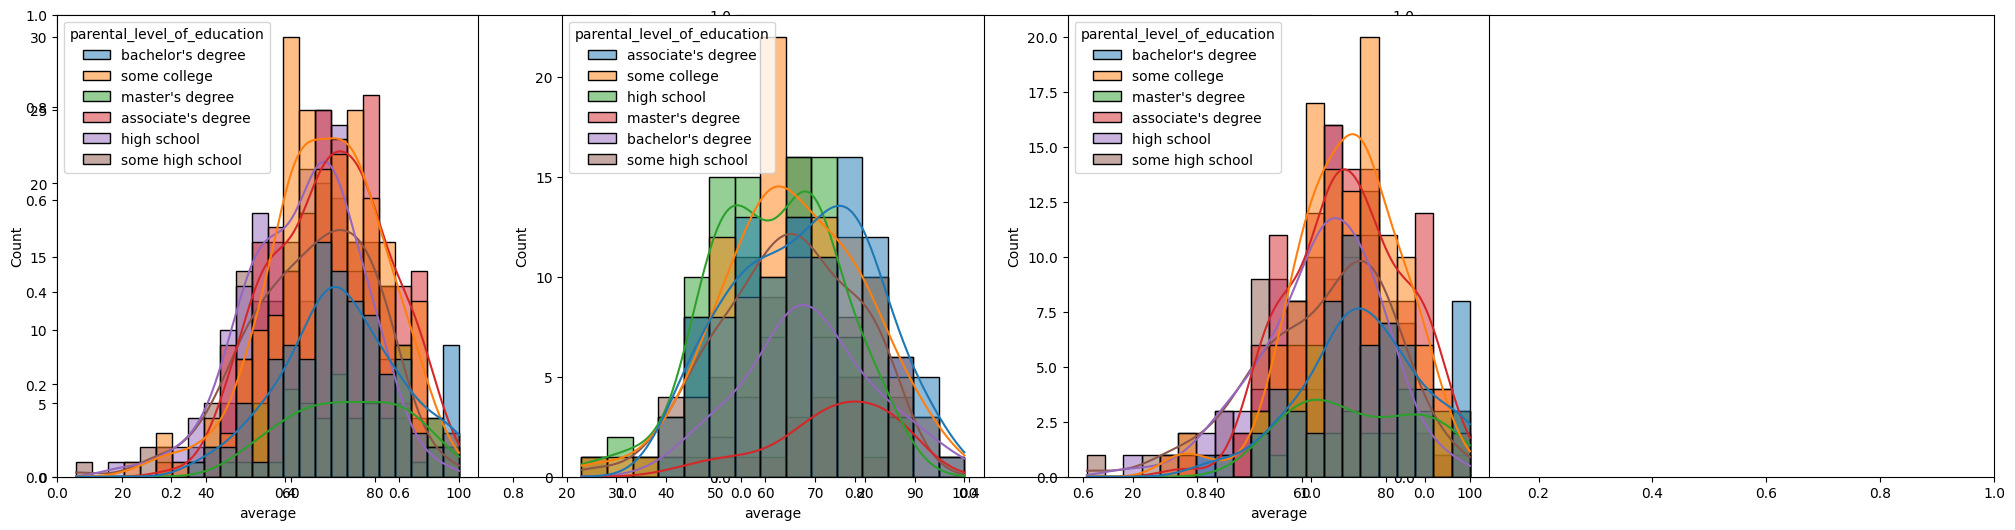

In [31]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='parental_level_of_education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental_level_of_education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental_level_of_education')
plt.show()

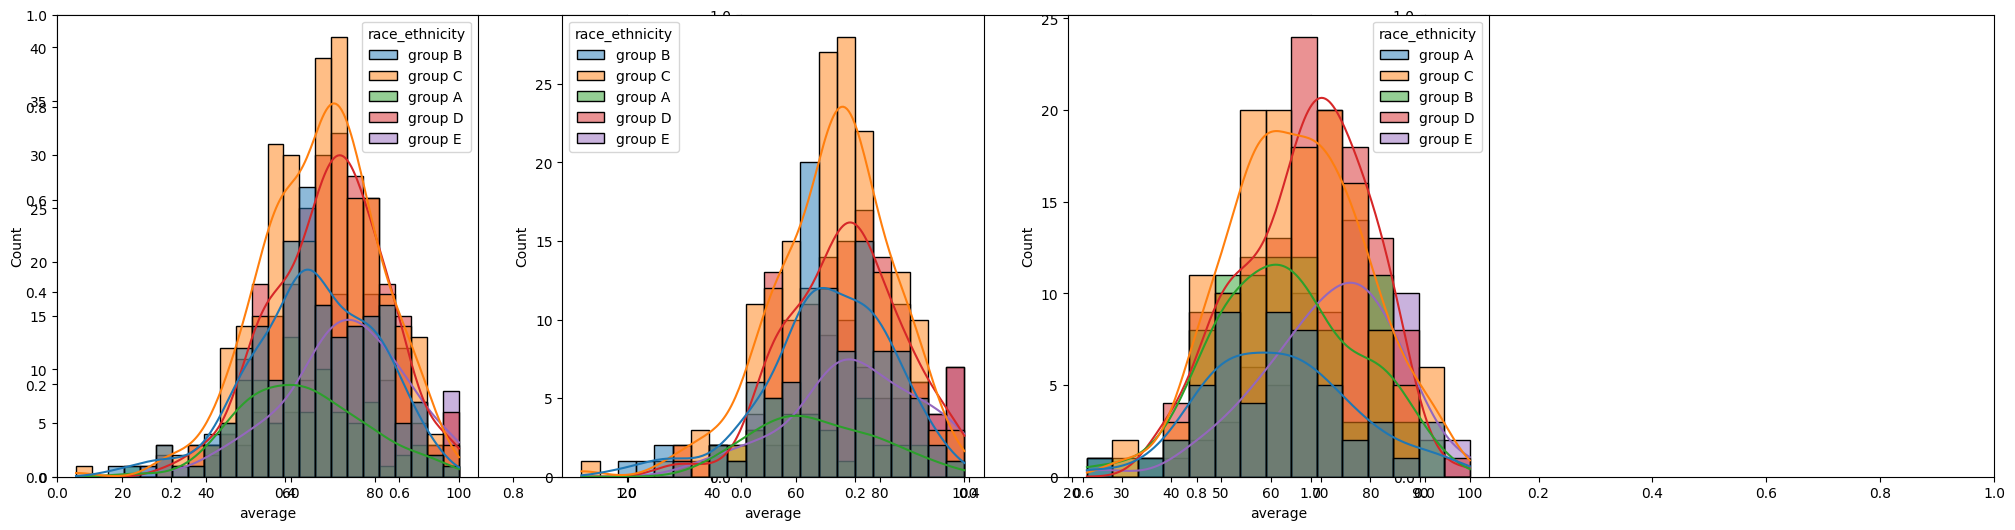

In [33]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='race_ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race_ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race_ethnicity')
plt.show()

#### Insights
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

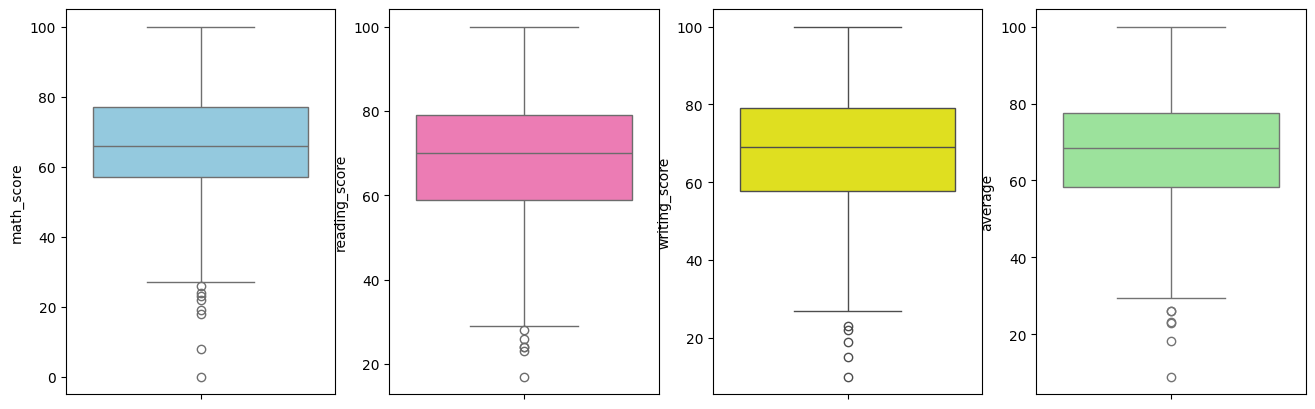

In [35]:
## checking outliers
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

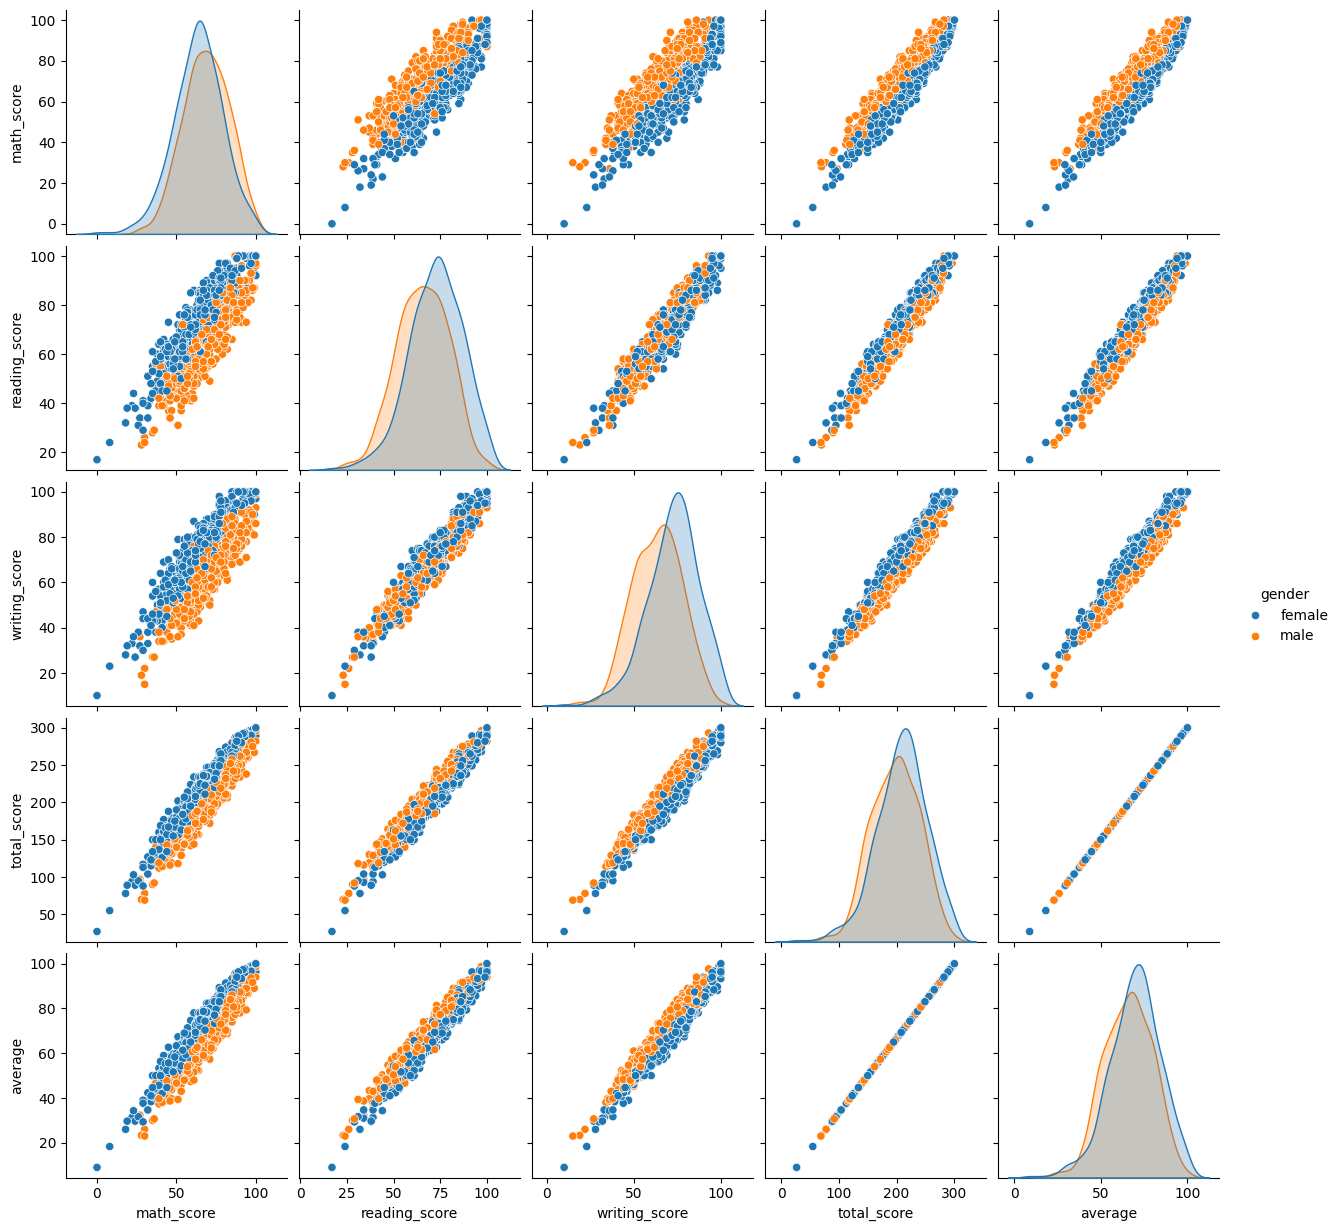

In [36]:
sns.pairplot(df,hue = 'gender')
plt.show()